<a href="https://colab.research.google.com/github/jannikm81-gif/Humanitas-purissima-/blob/main/notebooks/wealth_gradient_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

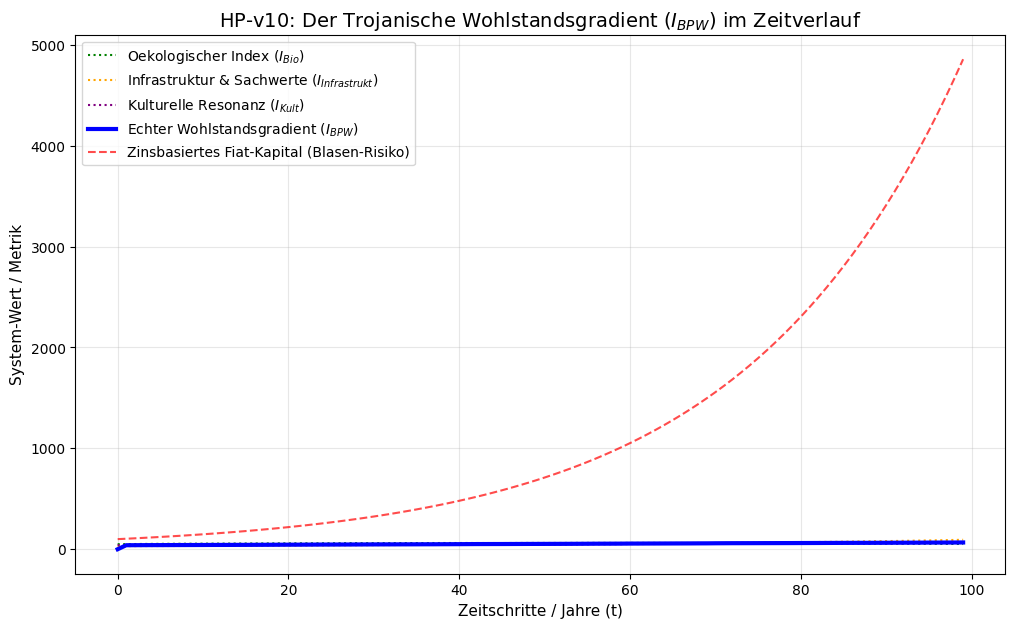

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_wealth_gradient(steps=100):
    np.random.seed(42)

    # Initiale Werte der Wohlstands-Indikatoren
    I_Bio = np.zeros(steps)          # Oekologische Regeneration
    I_Infrastrukt = np.zeros(steps)  # Sachwerte (Energie, Wasser, Wohnraum)
    I_Kult = np.zeros(steps)         # Kulturelle Resonanz / Kulanzfenster
    I_BPW = np.zeros(steps)          # Gesamt-Wohlstandsgradient (Real Wealth Index)

    # Startwerte
    I_Bio[0] = 50.0
    I_Infrastrukt[0] = 30.0
    I_Kult[0] = 40.0

    # Simulation des klassischen zinsbasierten Marktes zum Vergleich (Fiat-Metrik)
    fiat_capital = np.zeros(steps)
    fiat_capital[0] = 100.0
    interest_rate = 0.04 # 4% Zinseszins-Dynamik (erzeugt Inflation/Kollapsrisiko)

    for t in range(1, steps):
        # 1. Traditionelles System: Exponentielles Geldwachstum entkoppelt von der Realitaet
        fiat_capital[t] = fiat_capital[t-1] * (1 + interest_rate)

        # 2. HP-v10 Invariante: Der Trojanische Gradient saugt Liquiditaet ab
        # und wandelt sie in reale Sachwerte um (zinslose Reinvestition)
        drain_factor = 0.02 * (fiat_capital[t-1] / 100.0)

        # Entwicklung der drei Saeulen unter dem Protokoll
        # Oekologie waechst durch regenerative Anreize
        I_Bio[t] = I_Bio[t-1] + np.random.normal(0.5, 0.2) - (0.01 * t)

        # Infrastruktur waechst direkt durch den absorbierten Liquiditaetsstrom (Sachwertdeckung)
        I_Infrastrukt[t] = I_Infrastrukt[t-1] + (drain_factor * 1.5) + np.random.normal(0.3, 0.1)

        # Kulturelle Resonanz stabilisiert sich durch die algorithmischen Kulanzfenster
        I_Kult[t] = I_Kult[t-1] + np.random.normal(0.2, 0.3)

        # 3. Berechnung des echten Wohlstandsgradienten (I_BPW) als geometrisches Mittel
        # Verhindert, dass eine Saeule die Z zerstoert (z.B. totale Industrialisierung auf Kosten der Natur)
        I_BPW[t] = (I_Bio[t] * I_Infrastrukt[t] * I_Kult[t]) ** (1/3)

    return I_Bio, I_Infrastrukt, I_Kult, I_BPW, fiat_capital

# Simulation ausfuehren
I_Bio, I_Infrastrukt, I_Kult, I_BPW, fiat_capital = simulate_wealth_gradient()

# --- DIAGRAMM ZEICHNEN ---
plt.figure(figsize=(12, 7))

# Die drei Saeulen von Humanitas Purissima
plt.plot(I_Bio, label="Oekologischer Index ($I_{Bio}$)", color="green", linestyle=":")
plt.plot(I_Infrastrukt, label="Infrastruktur & Sachwerte ($I_{Infrastrukt}$)", color="orange", linestyle=":")
plt.plot(I_Kult, label="Kulturelle Resonanz ($I_{Kult}$)", color="purple", linestyle=":")

# Der resultierende echte Wohlstandsgradient vs. Fiat-Blase
plt.plot(I_BPW, label="Echter Wohlstandsgradient ($I_{BPW}$)", color="blue", linewidth=3)
plt.plot(fiat_capital, label="Zinsbasiertes Fiat-Kapital (Blasen-Risiko)", color="red", linestyle="--", alpha=0.7)

plt.title("HP-v10: Der Trojanische Wohlstandsgradient ($I_{BPW}$) im Zeitverlauf", fontsize=14)
plt.xlabel("Zeitschritte / Jahre (t)", fontsize=11)
plt.ylabel("System-Wert / Metrik", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

plt.show()